In [1]:
!pip install -q torch torchvision segmentation_models_pytorch albumentations opencv-python tqdm

In [1]:
import os
import csv
from typing import List, Tuple

import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from tqdm import tqdm

torch.set_printoptions(precision=4, sci_mode=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
class DepthDataset(Dataset):
    def __init__(
        self,
        csv_path: str,
        img_size: Tuple[int, int] = (480, 640),  # (H, W)
        is_train: bool = True,
        max_depth_val: float = 255.0,
    ):
        """
        csv_path: путь до csv (без хедера), каждая строка: rgb_path, depth_path
        img_size: (H, W) - конечный размер
        """
        self.samples = self._load_csv(csv_path)
        self.height, self.width = img_size
        self.is_train = is_train
        self.max_depth_val = max_depth_val

        self.mean = (0.485, 0.456, 0.406)
        self.std = (0.229, 0.224, 0.225)

        self.transform = self._build_augmentations()

    def _load_csv(self, csv_path: str) -> List[Tuple[str, str]]:
        samples = []
        with open(csv_path, "r") as f:
            reader = csv.reader(f)
            for row in reader:
                if len(row) < 2:
                    continue
                rgb_path, depth_path = row[0], row[1]
                samples.append((rgb_path, depth_path))
        return samples

    def _build_augmentations(self):
        H, W = self.height, self.width

        if self.is_train:
            return A.Compose(
                [
                    A.Resize(height=H, width=W, interpolation=cv2.INTER_LINEAR),
                    A.HorizontalFlip(p=0.5),
                    A.OneOf(
                        [
                            A.ColorJitter(
                                brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1
                            ),
                            A.RandomGamma(gamma_limit=(80, 120)),
                        ],
                        p=0.8,
                    ),
                    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
                    A.GaussNoise(var_limit=(5.0, 30.0), p=0.2),
                    A.Normalize(mean=self.mean, std=self.std),
                    ToTensorV2(),
                ],
                additional_targets={"depth": "mask"},
            )
        else:
            return A.Compose(
                [
                    A.Resize(height=H, width=W, interpolation=cv2.INTER_LINEAR),
                    A.Normalize(mean=self.mean, std=self.std),
                    ToTensorV2(),
                ],
                additional_targets={"depth": "mask"},
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rgb_path, depth_path = self.samples[idx]

        rgb = cv2.imread(rgb_path, cv2.IMREAD_COLOR)
        if rgb is None:
            raise FileNotFoundError(f"Cannot read image: {rgb_path}")
        rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)  # (H,W,3)

        depth = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)
        if depth is None:
            raise FileNotFoundError(f"Cannot read depth: {depth_path}")

        if depth.ndim == 3:
            depth = depth[..., 0]

        depth = depth.astype(np.float32) / self.max_depth_val
        depth = np.clip(depth, 0.0, 1.0)  # (H,W)

        augmented = self.transform(image=rgb, depth=depth)
        img = augmented["image"]      # [3,H,W]
        depth = augmented["depth"]    # [H,W]

        if img.shape[1] != self.height or img.shape[2] != self.width:
            raise RuntimeError(
                f"Unexpected image size after transform: {img.shape}, "
                f"expected [3,{self.height},{self.width}]"
            )
        if depth.shape[0] != self.height or depth.shape[1] != self.width:
            raise RuntimeError(
                f"Unexpected depth size after transform: {depth.shape}, "
                f"expected [{self.height},{self.width}]"
            )

        depth = depth.unsqueeze(0).float()  # [1,H,W]

        return img, depth

In [3]:
def build_model(
    encoder_name: str = "resnet101", # se_resnext50_32x4d efficientnet-b7
    encoder_weights: str = "imagenet", # timm
    in_channels: int = 3,
    classes: int = 1,
) -> nn.Module:
    """
    encoder_name: 'resnet34' или 'resnet50'
    classes: 1, т.к. мы предсказываем одну карту глубины
    """
    model = smp.Unet(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=in_channels,
        classes=classes,
        activation=None,
    )
    return model

In [4]:
class GradLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.L1Loss()

    def forward(self, pred, target):
        def gradient_x(img):
            gx = img[..., :, 1:] - img[..., :, :-1]  # [B,1,H,W-1]
            return gx

        def gradient_y(img):
            gy = img[..., 1:, :] - img[..., :-1, :]  # [B,1,H-1,W]
            return gy

        pred_dx = gradient_x(pred)
        pred_dy = gradient_y(pred)
        target_dx = gradient_x(target)
        target_dy = gradient_y(target)

        loss_dx = self.l1(pred_dx, target_dx)
        loss_dy = self.l1(pred_dy, target_dy)
        return loss_dx + loss_dy


class LogL1Loss(nn.Module):
    """
    L1 в логарифмическом пространстве глубины: L1(log(pred+eps) - log(gt+eps))
    """

    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.l1 = nn.L1Loss()

    def forward(self, pred, target):
        # Обрезаем предсказание, чтобы не было <0
        pred = torch.clamp(pred, min=0.0, max=1.0)
        target = torch.clamp(target, min=0.0, max=1.0)

        pred_log = torch.log(pred * 1.0 + self.eps)
        target_log = torch.log(target * 1.0 + self.eps)

        return self.l1(pred_log, target_log)


class DepthLoss(nn.Module):
    def __init__(self, w_l1=1.0, w_grad=0.5, use_log_l1=True):
        super().__init__()
        self.use_log_l1 = use_log_l1
        self.w_l1 = w_l1
        self.w_grad = w_grad

        if use_log_l1:
            self.l1_loss = LogL1Loss()
        else:
            self.l1_loss = nn.L1Loss()

        self.grad_loss = GradLoss()

    def forward(self, pred, target):
        l1 = self.l1_loss(pred, target)
        grad = self.grad_loss(pred, target)
        loss = self.w_l1 * l1 + self.w_grad * grad
        return loss, {"l1": l1.item(), "grad": grad.item()}

In [5]:
@torch.no_grad()
def depth_metrics(pred, target, eps=1e-6):
    pred = torch.clamp(pred, 0.0, 1.0)
    target = torch.clamp(target, 0.0, 1.0)

    # Flatten
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)

    # MAE
    mae = torch.mean(torch.abs(pred_flat - target_flat))

    # RMSE
    rmse = torch.sqrt(torch.mean((pred_flat - target_flat) ** 2))

    # δ1
    mask = target_flat > eps
    pred_flat = pred_flat[mask]
    target_flat = target_flat[mask]

    ratio = torch.max(pred_flat / target_flat, target_flat / pred_flat)
    delta1 = torch.mean((ratio < 1.25).float())

    return {
        "mae": mae.item(),
        "rmse": rmse.item(),
        "delta1": delta1.item(),
    }

In [6]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    loss_fn,
    device,
    scheduler,
    scaler=None,
):
    model.train()
    total_loss = 0.0
    total_l1 = 0.0
    total_grad = 0.0

    pbar = tqdm(loader, desc="Train", leave=False)

    for imgs, depths in pbar:
        imgs = imgs.to(device)           # [B,3,H,W]
        depths = depths.to(device)       # [B,1,H,W]

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=scaler is not None):
            preds = model(imgs)          # [B,1,H,W]
            loss, loss_dict = loss_fn(preds, depths)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        
        total_loss += loss.item() * imgs.size(0)
        total_l1 += loss_dict["l1"] * imgs.size(0)
        total_grad += loss_dict["grad"] * imgs.size(0)

        pbar.set_postfix(
            loss=loss.item(), l1=loss_dict["l1"], grad=loss_dict["grad"]
        )

    scheduler.step()
    
    n = len(loader.dataset)
    return {
        "loss": total_loss / n,
        "l1": total_l1 / n,
        "grad": total_grad / n,
    }


@torch.no_grad()
def validate(
    model,
    loader,
    loss_fn,
    device,
):
    model.eval()
    total_loss = 0.0
    total_l1 = 0.0
    total_grad = 0.0

    total_mae = 0.0
    total_rmse = 0.0
    total_delta1 = 0.0
    total_n = 0

    pbar = tqdm(loader, desc="Val", leave=False)

    for imgs, depths in pbar:
        imgs = imgs.to(device)
        depths = depths.to(device)

        preds = model(imgs)

        loss, loss_dict = loss_fn(preds, depths)
        metrics = depth_metrics(preds, depths)

        bs = imgs.size(0)
        total_n += bs

        total_loss += loss.item() * bs
        total_l1 += loss_dict["l1"] * bs
        total_grad += loss_dict["grad"] * bs

        total_mae += metrics["mae"] * bs
        total_rmse += metrics["rmse"] * bs
        total_delta1 += metrics["delta1"] * bs

        pbar.set_postfix(
            loss=loss.item(), mae=metrics["mae"], rmse=metrics["rmse"], d1=metrics["delta1"]
        )

    return {
        "loss": total_loss / total_n,
        "l1": total_l1 / total_n,
        "grad": total_grad / total_n,
        "mae": total_mae / total_n,
        "rmse": total_rmse / total_n,
        "delta1": total_delta1 / total_n,
    }

In [7]:
synthetic_csv = "./synthetic_data/synthetic_data.csv"
real_csv = "./data/nyu2_train.csv"
encoder_name = "efficientnet-b7" # resnet34 "resnet101" efficientnet-b7 
encoder_weights_name = "advprop" # imagenet timm advprop
img_height, img_width = 480, 640
batch_size = 8

img_size = (img_height, img_width)

train_dataset = DepthDataset(
    csv_path=synthetic_csv,
    img_size=img_size,
    is_train=True,
    max_depth_val=255.0,
)

val_dataset = DepthDataset(
    csv_path=real_csv,
    img_size=img_size,
    is_train=False,
    max_depth_val=255.0,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

len(train_dataset), len(val_dataset)

FileNotFoundError: [Errno 2] No such file or directory: './synthetic_data/synthetic_data.csv'

In [9]:
from torch.optim.lr_scheduler import CosineAnnealingLR

num_epochs = 50

model = build_model(
    encoder_name=encoder_name,
    encoder_weights=encoder_weights_name,
    in_channels=3,
    classes=1,
)
model.to(device)

loss_fn = DepthLoss(w_l1=1.0, w_grad=0.5, use_log_l1=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

use_mixed_precision = True
scaler = torch.cuda.amp.GradScaler() if use_mixed_precision else None

model

/tmp/ipykernel_1460727/1897542563.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if use_mixed_precision else None


Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 64, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          64, 16, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          16, 64, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Ident

In [10]:
import math
history = {
    "train_loss": [],
    "val_loss": [],
    "val_rmse": [],
    "val_delta1": [],
}
start_epoch = 1
best_rmse = math.inf
output_dir = "./checkpoints_unet"
os.makedirs(output_dir, exist_ok=True)

In [11]:
checkpoint_path = lst_path = os.path.join(output_dir, f"best_{encoder_name}_lst.pth")
checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])
start_epoch = checkpoint['epoch'] + 1
history = checkpoint['history']
val_stats = checkpoint['val_stats']
best_rmse = checkpoint['best_rmse'] if "best_rmse" in checkpoint else math.inf

In [12]:
for epoch in range(start_epoch, num_epochs + 1):
    print(f"\nEpoch {epoch}/{num_epochs}")

    train_stats = train_one_epoch(
        model,
        train_loader,
        optimizer,
        loss_fn,
        device,
        scheduler,
        scaler=scaler,
    )
    print(
        f"Train: loss={train_stats['loss']:.4f}, "
        f"l1={train_stats['l1']:.4f}, grad={train_stats['grad']:.4f}"
    )

    val_stats = validate(
        model,
        val_loader,
        loss_fn,
        device,
    )
    print(
        f"Val: loss={val_stats['loss']:.4f}, "
        f"l1={val_stats['l1']:.4f}, grad={val_stats['grad']:.4f}, "
        f"mae={val_stats['mae']:.4f}, rmse={val_stats['rmse']:.4f}, "
        f"delta1={val_stats['delta1']:.4f}"
    )

    history["train_loss"].append(train_stats["loss"])
    history["val_loss"].append(val_stats["loss"])
    history["val_rmse"].append(val_stats["rmse"])
    history["val_delta1"].append(val_stats["delta1"])

    if val_stats["rmse"] < best_rmse:
        best_rmse = val_stats["rmse"]
        ckpt_path = os.path.join(
            output_dir,
            f"best_{encoder_name}_rmse_{best_rmse:.4f}.pth",
        )
        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_stats": val_stats,
                "history": history,
                "best_rmse": best_rmse,
            },
            ckpt_path,
        )
        print(f"Saved best model to {ckpt_path}")

    lst_path = os.path.join(
        output_dir,
        f"best_{encoder_name}_lst.pth",
    )
    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_stats": val_stats,
            "history": history,
            "best_rmse": best_rmse,
        },
        lst_path,
    )
    print(f"Saved last model to {lst_path}")


Epoch 23/50


Train:   0%|                                                                                  | 0/22500 [00:00<?, ?it/s]/tmp/ipykernel_1460727/4017759275.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):
                                                                                                                        

Train: loss=0.0252, l1=0.0246, grad=0.0013


Val: loss=0.8381, l1=0.8360, grad=0.0041, mae=0.1694, rmse=0.2032, delta1=0.1028
Saved last model to ./checkpoints_unet/best_efficientnet-b7_lst.pth

Epoch 24/50


Train: loss=0.0251, l1=0.0245, grad=0.0012


...

Train: loss=0.0233, l1=0.0228, grad=0.0011


Val: loss=0.8486, l1=0.8471, grad=0.0030, mae=0.1726, rmse=0.2072, delta1=0.1020
Saved last model to ./checkpoints_unet/best_efficientnet-b7_lst.pth

Epoch 29/50


Train: loss=0.0232, l1=0.0226, grad=0.0013


Val: loss=0.8559, l1=0.8545, grad=0.0030, mae=0.1740, rmse=0.2093, delta1=0.1036
Saved last model to ./checkpoints_unet/best_efficientnet-b7_lst.pth

Epoch 30/50


KeyboardInterrupt: 

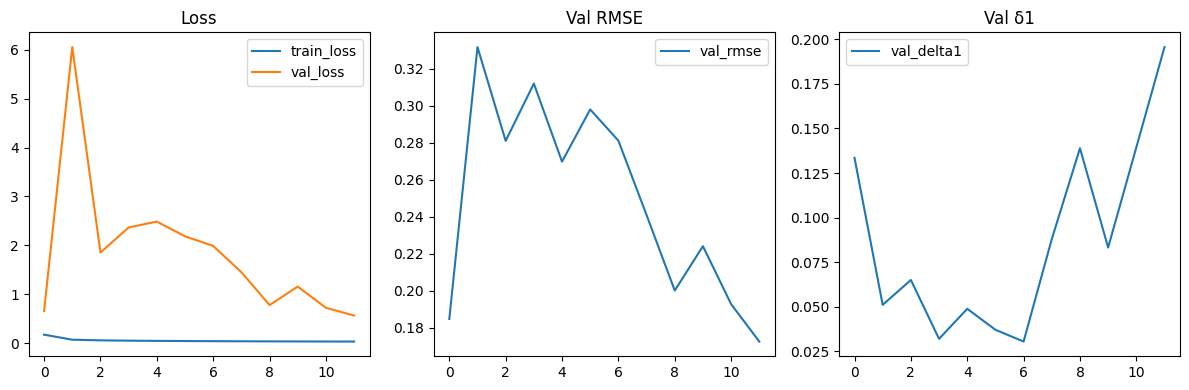

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(history["train_loss"][1:], label="train_loss")
plt.plot(history["val_loss"][1:], label="val_loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,3,2)
plt.plot(history["val_rmse"][1:], label="val_rmse")
plt.legend()
plt.title("Val RMSE")

plt.subplot(1,3,3)
plt.plot(history["val_delta1"][1:], label="val_delta1")
plt.legend()
plt.title("Val δ1")

plt.tight_layout()
plt.show()

In [10]:
"""
encoder_name = "se_resnext50_32x4d" # resnet34  # или se_resnext50_32x4d
encoder_weights_name = "imagenet" # timm

model = build_model(
    encoder_name=encoder_name,
    encoder_weights=encoder_weights_name,
    in_channels=3,
    classes=1,
)

ckpt = torch.load("./checkpoints_unet/best_se_resnext50_32x4d_rmse_0.1927.pth", map_location=device) # best_se_resnext50_32x4d_rmse_0.1927.pth
model.load_state_dict(ckpt["model_state"])
model.to(device)  
model.eval()
"""

Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 64, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          64, 16, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          16, 64, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Ident

In [11]:
history = ckpt["history"]

In [ ]:
import matplotlib.pyplot as plt

def visualize_sample(model, dataset, idx=0):
    model.eval()
    img, depth_gt = dataset[idx]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        pred = torch.clamp(pred, 0.0, 1.0).cpu().squeeze().numpy()
    depth_gt_np = depth_gt.squeeze().numpy()
    img_np = img.permute(1,2,0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_vis = (img_np * std + mean)
    img_vis = np.clip(img_vis, 0, 1)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(img_vis)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(depth_gt_np, cmap="magma")
    plt.title("GT depth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred, cmap="magma")
    plt.title("Pred depth")
    plt.axis("off")

    plt.show()

visualize_sample(model, val_dataset, idx=800)